In [1]:
###############################################################################################################################
# IMPORT NECESSARY PACKAGES : 
###############################################################################################################################
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm  # For logarithmic color scaling
import datetime as dt
import os
from typing import Tuple, Optional, Union, List

# TOOLBOX PATH :
oai_path = '/lustre/storeB/project/fou/hi/foccus/ingvild/ocean-ai'
import sys
sys.path.append(oai_path+'/plot/analysis')
from dataloader import open_dataset
from dataloader_inf import *

In [ ]:
inference_path = '/lustre/storeB/project/fou/hi/foccus/ingvild/test_infrence/results/2024-04-02_72h_18d28_e011_s049990.nc'
inference_path = '/lustre/storeB/project/fou/hi/foccus/ingvild/test_infrence/results/2024-04-02_48h_18d28_e011_s050000.nc'
#inference_path = '/lustre/storeB/project/fou/hi/foccus/ingvild/test_infrence/results/2024-04-02_48h_18d28_e002_s013968.nc'
#inference_path = '/lustre/storeB/project/fou/hi/foccus/ingvild/test_infrence/results/2024-04-02_72h_e5281_e025_s098000.nc'
#inference_path = '/lustre/storeB/project/fou/hi/foccus/experiments/2m-depth/results/2024-04-02_48h_e655e_e013_s054000.nc'


havbris, norkyst3 = open_dataset_inf(inference_path, crop_border=False, s_rho = -1,
                                         variables=['temperature', 'u_eastward', 'v_northward', 'salinity'],)

In [2]:
inference_path           = '/lustre/storeB/project/fou/hi/foccus/experiments/2m-depth/results/2024-04-02_48h_e655e_e013_s054000.nc'
truth_norkyst3_path      = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3_zdepth-hindcast'
truth_file_name_template = "{year}/norkyst800-{year}{month:02d}{day:02d}.nc"

havbris, norkyst3 = open_dataset_inf(path_to_inf = inference_path,
                                     truth_norkyst3_path = truth_norkyst3_path,
                                     truth_file_name_template = truth_file_name_template,
                                     variables=["salinity", "temperature", "u_eastward", "v_northward"],
                                     s_rho = -1,
                                     depth = 2, 
                                     crop_border = True,
                                     debug       = True)

Try to read file : /lustre/storeB/project/fou/hi/foccus/experiments/2m-depth/results/2024-04-02_48h_e655e_e013_s054000.nc

File exists!

File exists and is read!

Variables in the dataset:
['lat', 'lon', 'salinity_2', 'temperature_2', 'u_eastward_2', 'v_northward_2']

Inferred time-steps:
['2024-04-02T03:00:00.000000000' '2024-04-02T06:00:00.000000000'
 '2024-04-02T09:00:00.000000000' '2024-04-02T12:00:00.000000000'
 '2024-04-02T15:00:00.000000000' '2024-04-02T18:00:00.000000000'
 '2024-04-02T21:00:00.000000000' '2024-04-03T00:00:00.000000000'
 '2024-04-03T03:00:00.000000000' '2024-04-03T06:00:00.000000000'
 '2024-04-03T09:00:00.000000000' '2024-04-03T12:00:00.000000000'
 '2024-04-03T15:00:00.000000000' '2024-04-03T18:00:00.000000000'
 '2024-04-03T21:00:00.000000000' '2024-04-04T00:00:00.000000000']
Unique days:
['2024-04-02' '2024-04-03' '2024-04-04']
Unique days : ['2024-04-02' '2024-04-03' '2024-04-04']

valid_time:2024-04-02 00:00:00

file_name:2024/norkyst800-20240402.nc

full_fil

In [5]:
def scatter_log(norkyst_data,#=norkyst3.v_northward.values, 
                havbris_data,#=havbris.v_northward_2.values,
                variable_name='V Northward'):
    # Mask NaNs (ensure both datasets align and exclude NaNs in either dataset)
    valid_mask = ~np.isnan(norkyst_data) & ~np.isnan(havbris_data)
    norkyst3_clean = norkyst_data[valid_mask]
    havbris_clean  = havbris_data[valid_mask]
    # Reshape into the original spatial dimensions for plotting purposes
    norkyst3_clean_spatial = norkyst_data.copy()
    havbris_clean_spatial  = havbris_data.copy()
    norkyst3_clean_spatial[~valid_mask] = np.nan
    havbris_clean_spatial[~valid_mask]  = np.nan
    # 1. Spatial Correlation
    correlation = np.corrcoef(norkyst3_clean, havbris_clean)[0, 1]
    print(f"Spatial Correlation: {correlation}")
    # 2. Scatter Plot with Heatmap Effect (Logarithmic Color Scaling)
    plt.figure(figsize=(12, 10))
    # Use hexbin for heatmap effect with logarithmic scaling
    hb = plt.hexbin(
        norkyst3_clean, 
        havbris_clean, 
        gridsize=300, 
        cmap='viridis', 
        mincnt=1,  # Ignore bins with no data
        norm=LogNorm()  # Apply logarithmic scaling to the color
    )
    # Add colorbar to display density
    cb = plt.colorbar(hb)
    cb.set_label('Log Counts')
    # Plot the 1:1 line
    plt.plot(
        [np.nanmin(norkyst_data), np.nanmax(norkyst_data)], 
        [np.nanmin(norkyst_data), np.nanmax(norkyst_data)], 
        color='red', linestyle='--', label='1:1 Line'
    )
    # Calculate the same limits for both x and y axes
    data_min = min(np.nanmin(norkyst3_clean), np.nanmin(havbris_clean))
    data_max = max(np.nanmax(norkyst3_clean), np.nanmax(havbris_clean))
    plt.xlim(data_min, data_max)
    plt.ylim(data_min, data_max)
    plt.xlabel(f'Norkyst {variable_name}')
    plt.ylabel(f'Havbris {variable_name}')
    plt.title(f'Heatmap Scatter Plot of {variable_name} (Log Scaled)')
    plt.legend()
    #plt.grid()
    plt.show()

def scatter(norkyst_data,#=norkyst3.v_northward.values, 
            havbris_data,#=havbris.v_northward_2.values,
            variable_name='V Northward'):
    # Mask NaNs (ensure both datasets align and exclude NaNs in either dataset)
    valid_mask = ~np.isnan(norkyst_data) & ~np.isnan(havbris_data)
    norkyst3_clean = norkyst_data[valid_mask]
    havbris_clean  = havbris_data[valid_mask]
    # Reshape into the original spatial dimensions for plotting purposes
    norkyst3_clean_spatial = norkyst_data.copy()
    havbris_clean_spatial  = havbris_data.copy()
    norkyst3_clean_spatial[~valid_mask] = np.nan
    havbris_clean_spatial[~valid_mask]  = np.nan
    # 1. Spatial Correlation
    correlation = np.corrcoef(norkyst3_clean, havbris_clean)[0, 1]
    print(f"Spatial Correlation: {correlation}")
    # 2. Scatter Plot
    plt.figure(figsize=(10,10))
    plt.scatter(norkyst3_clean, havbris_clean, alpha=0.5, s=2)
    plt.plot([np.nanmin(norkyst_data), np.nanmax(norkyst_data)], 
            [np.nanmin(norkyst_data), np.nanmax(norkyst_data)], 
            color='red', linestyle='--', label='1:1 Line')
    plt.xlabel(f'Norkyst {variable_name}')
    plt.ylabel(f'Havbris {variable_name}')
    plt.title(f'Scatter Plot of {variable_name}')
    plt.legend()
    plt.grid()
    plt.show()

def scatter_with_fit(norkyst_data,#=norkyst3.v_northward.values, 
                     havbris_data,#=havbris.v_northward_2.values,
                     variable_name='V Northward'):
    # Mask NaNs (ensure both datasets align and exclude NaNs in either dataset)
    valid_mask = ~np.isnan(norkyst_data) & ~np.isnan(havbris_data)
    norkyst3_clean = norkyst_data[valid_mask]
    havbris_clean  = havbris_data[valid_mask]
    # 1. Scatter Plot
    plt.figure(figsize=(10, 10))
    plt.scatter(norkyst3_clean, havbris_clean, alpha=0.5, s=2, label='Scatter Points')
    # Plot 1-to-1 Line (Reference Line)
    plt.plot([np.nanmin(norkyst3_clean), np.nanmax(norkyst3_clean)], 
             [np.nanmin(norkyst3_clean), np.nanmax(norkyst3_clean)], 
            color='red', linestyle='--', label='1:1 Line')
    # Linear Fit
    linear_fit = np.polyfit(norkyst3_clean, havbris_clean, 1)  # Degree 1 (linear)
    linear_line = np.polyval(linear_fit, norkyst3_clean)
    plt.plot(norkyst3_clean, linear_line, color='purple', label='Linear Fit', alpha=0.8)
    # Final Plot Details
    plt.xlabel(f'Norkyst {variable_name}')
    plt.ylabel(f'Havbris {variable_name}')
    plt.title(f'Scatter Plot of {variable_name} with Linear Fits')
    plt.legend()
    plt.grid()
    plt.show()

def mean_var_scatter(norkyst_data,#=norkyst3.v_northward.values, 
                     havbris_data,#=havbris.v_northward_2.values,
                     variable_name='V Northward'):
    # Mask NaNs (ensure both datasets align and exclude NaNs in either dataset)
    valid_mask = ~np.isnan(norkyst_data) & ~np.isnan(havbris_data)
    norkyst3_clean = norkyst_data[valid_mask]
    havbris_clean  = havbris_data[valid_mask]
    # Reshape into the original spatial dimensions for plotting purposes
    norkyst3_clean_spatial = norkyst_data.copy()
    havbris_clean_spatial  = havbris_data.copy()
    norkyst3_clean_spatial[~valid_mask] = np.nan
    havbris_clean_spatial[~valid_mask]  = np.nan
    # Bin data and calculate statistics
    bins = np.linspace(np.nanmin(norkyst3_clean), np.nanmax(norkyst3_clean), 50)
    bin_indices = np.digitize(norkyst3_clean, bins)
    bin_means = [havbris_clean[bin_indices == i].mean() for i in range(1, len(bins))]
    bin_stds  = [havbris_clean[bin_indices == i].std() for i in range(1, len(bins))]
    # Plot the mean and variance
    plt.figure(figsize=(10, 10))
    plt.errorbar(bins[:-1], bin_means, yerr=bin_stds, fmt='o', label='Mean ± Std', color='blue', ecolor='gray')
    plt.xlabel(f'Norkyst {variable_name}')
    plt.ylabel(f'Mean Havbris {variable_name}')
    plt.title(f'Mean and Variance of Havbris {variable_name} by Norkyst {variable_name}')
    plt.legend()
    plt.grid()
    plt.show()


Spatial Correlation: 0.9967263348652406


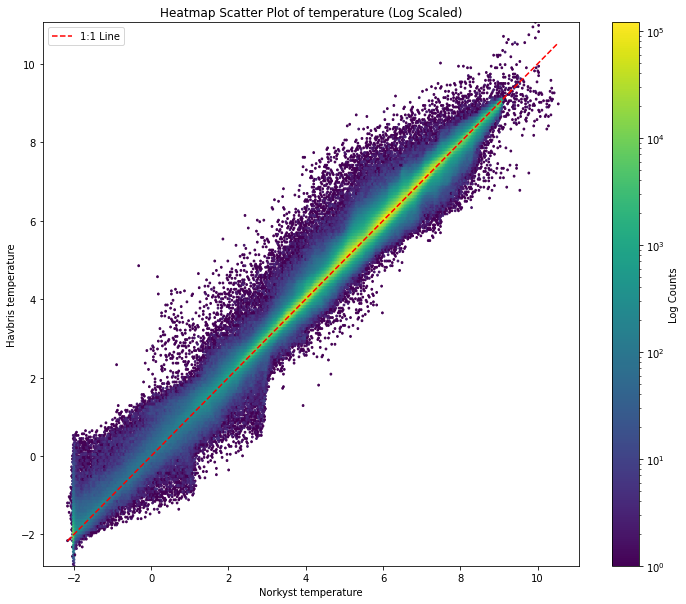

Spatial Correlation: 0.981766375451338


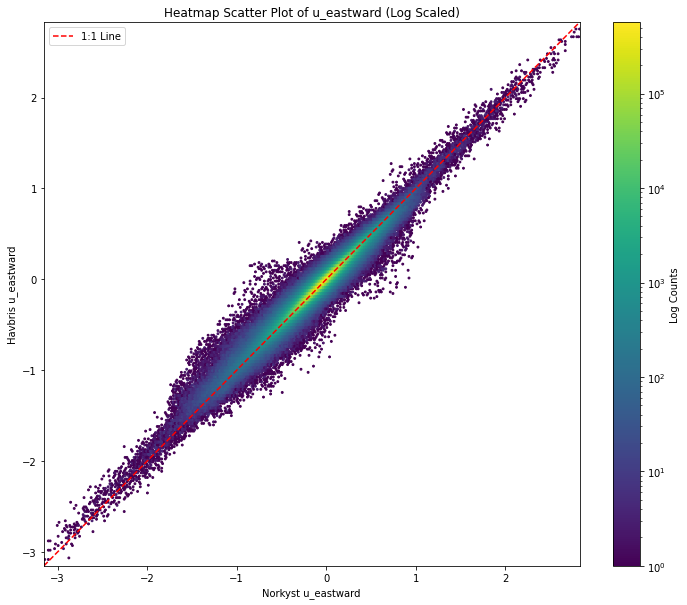

Spatial Correlation: 0.9779531963489396


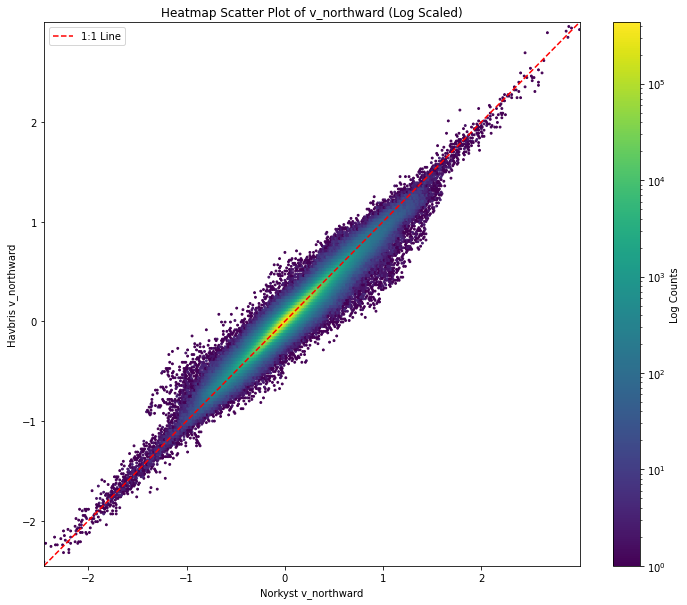

Spatial Correlation: 0.9705853241653545


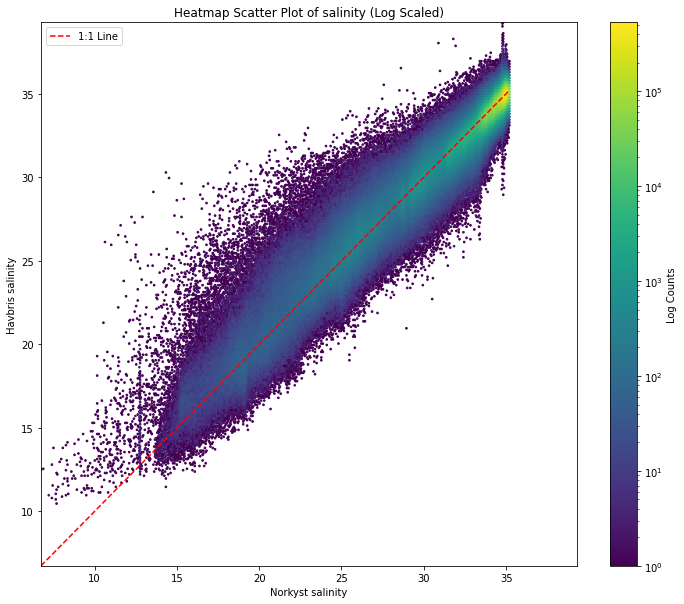

In [7]:
variable_list = ['temperature', 'u_eastward', 'v_northward', 'salinity']

for variable in variable_list:
    '''scatter_with_fit(norkyst_data=norkyst3[variable].values, 
                     havbris_data=havbris[variable].values,
                     variable_name=variable)'''
    '''mean_var_scatter(norkyst_data=norkyst3[variable].values, 
                     havbris_data=havbris[variable].values,
                     variable_name=variable)'''
    scatter_log(norkyst_data=norkyst3[variable].values, 
                havbris_data=havbris[variable].values,
                variable_name=variable)

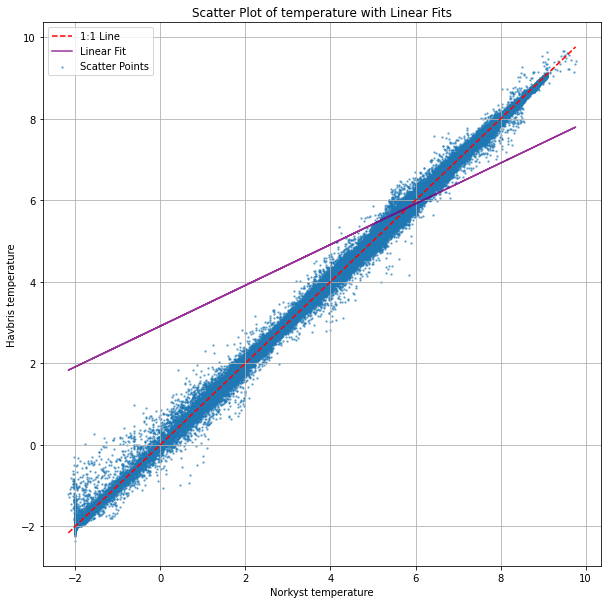

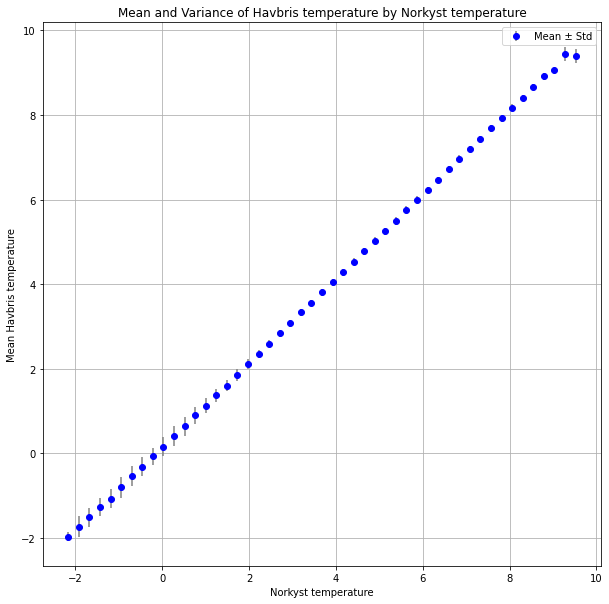

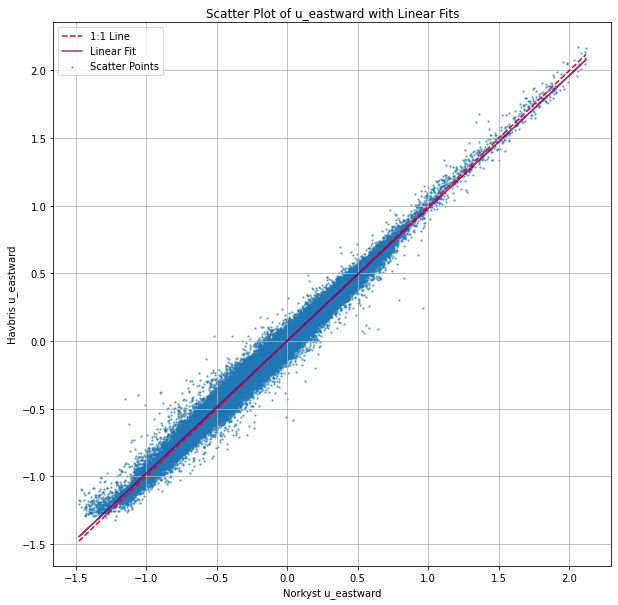

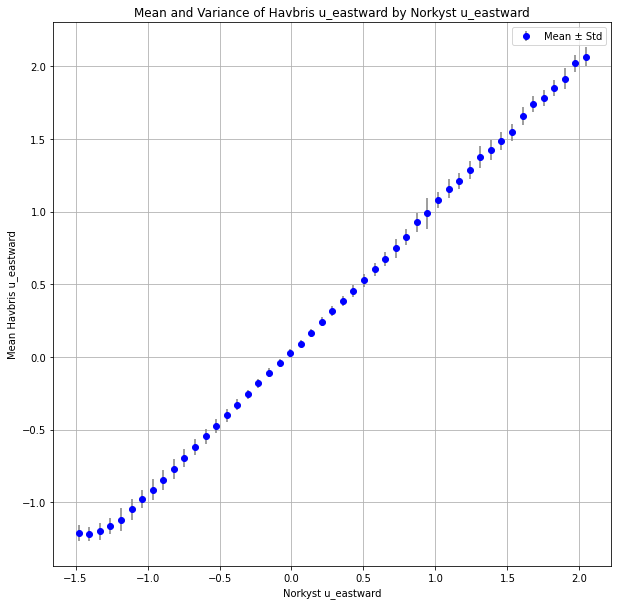

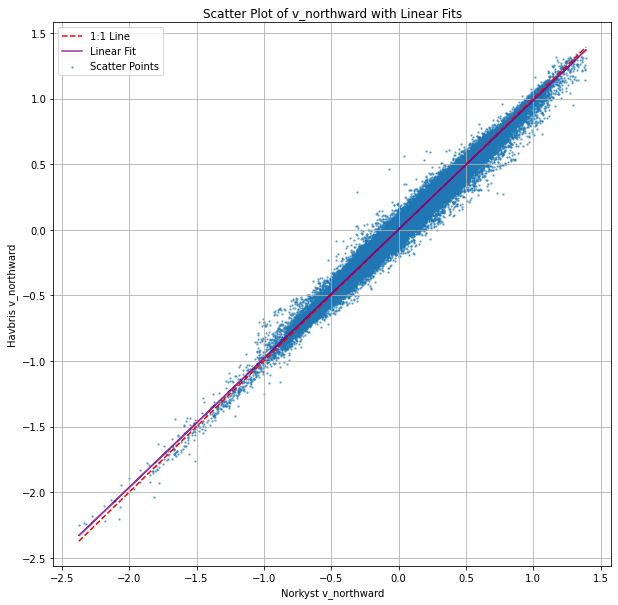

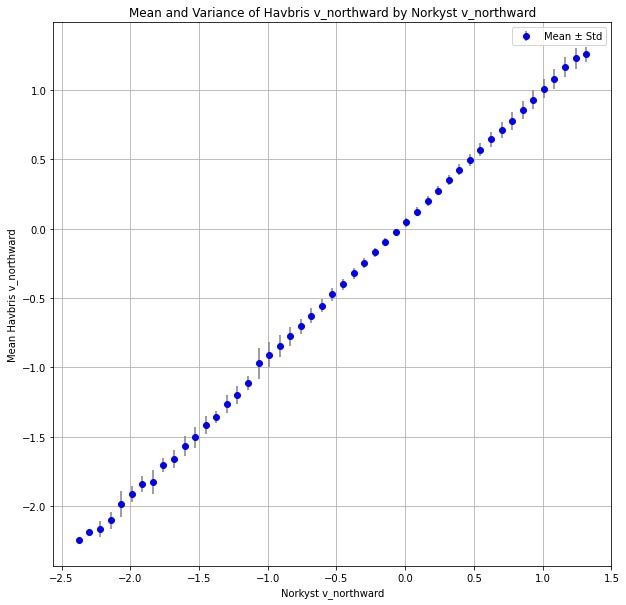

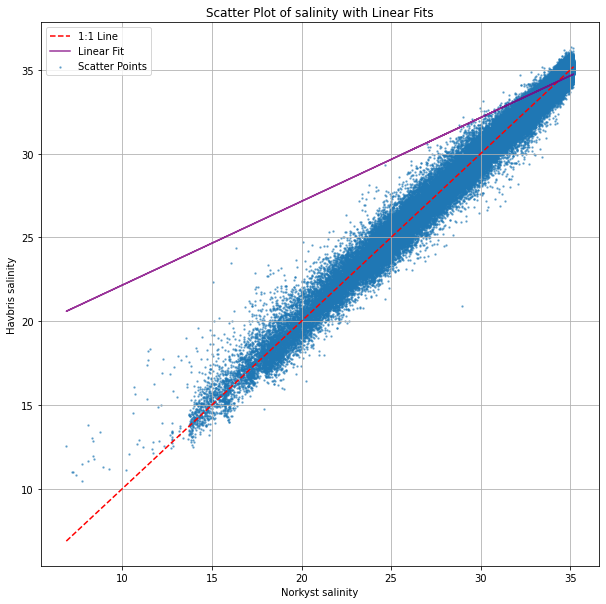

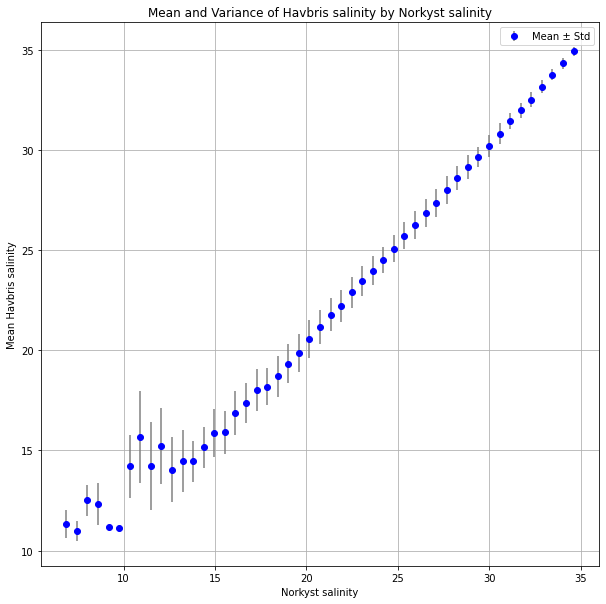

In [6]:
variable_list = ['temperature', 'u_eastward', 'v_northward', 'salinity']

for variable in variable_list:
    scatter_with_fit(norkyst_data=norkyst3[variable].isel(time=0).values, 
                     havbris_data=havbris[variable].isel(time=0).values,
                     variable_name=variable)
    mean_var_scatter(norkyst_data=norkyst3[variable].isel(time=0).values, 
                     havbris_data=havbris[variable].isel(time=0).values,
                     variable_name=variable)
    '''scatter_log(norkyst_data=norkyst3[variable].isel(time=0).values, 
                havbris_data=havbris[variable].isel(time=0).values,
                variable_name=variable)'''